=== DATA MENTAH ===
           NIM                Name  KUIS  UTS  UAS  Nilai Grade
0   2455301127     Muhammad Sarvin    80   79   90  83.17     A
1       120001            John Doe    85   78   90  84.44     A
2       120005          Jane Smith    92   88   94  91.38     A
3       120017     Michael Johnson    48   65   56  56.41     D
4       120018         Emily Brown    90   85   88  87.65     A
5       120022     Daniel Martinez    75   80   77  77.35     B
6       120024        Sarah Wilson    88   70   65  74.01     C
7       120025        David Garcia    75   70   75  73.35     C
8       120027         Jessica Lee    95   91   96  94.03     A
9       120034       Matthew Davis    79   84   78  80.30     B
10      120035  Jennifer Rodriguez    42   48   63  51.33     E
11      120036       Andrew Taylor    53   64   59  58.73     D
12      120038    Amanda Hernandez    91   95   90  91.97     A
13      120039   Christopher Clark    76   81   75  77.30     B
14      120046  Eliz

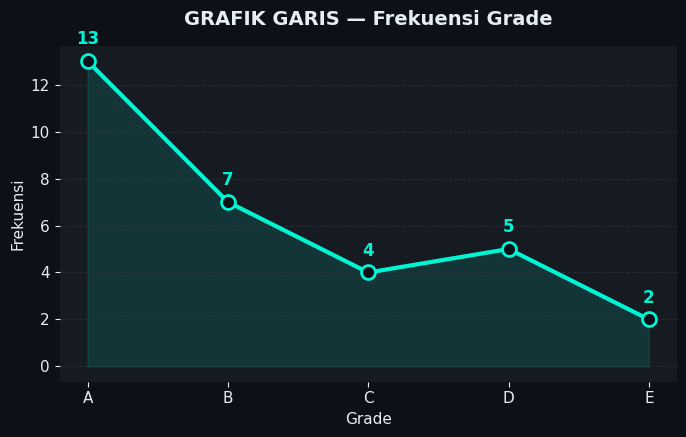

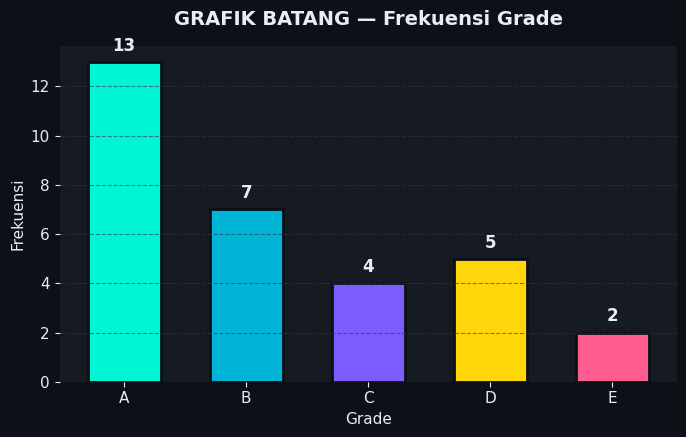

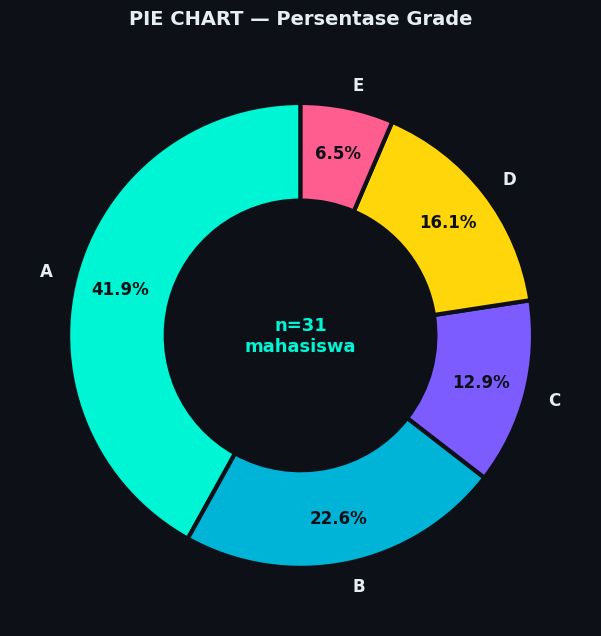


=== STATISTIKA DESKRIPTIF - NILAI AKHIR ===
count              31.000000
mean               76.445484
std                13.298929
min                46.010000
25%                68.800000
50%                79.300000
75%                86.790000
max                94.030000
Standard Error      2.388558
Median             79.300000
Mode               77.300000
variance          176.861506
range              48.020000
skewness           -0.714082
kurtosis           -0.433087
Name: Nilai, dtype: float64


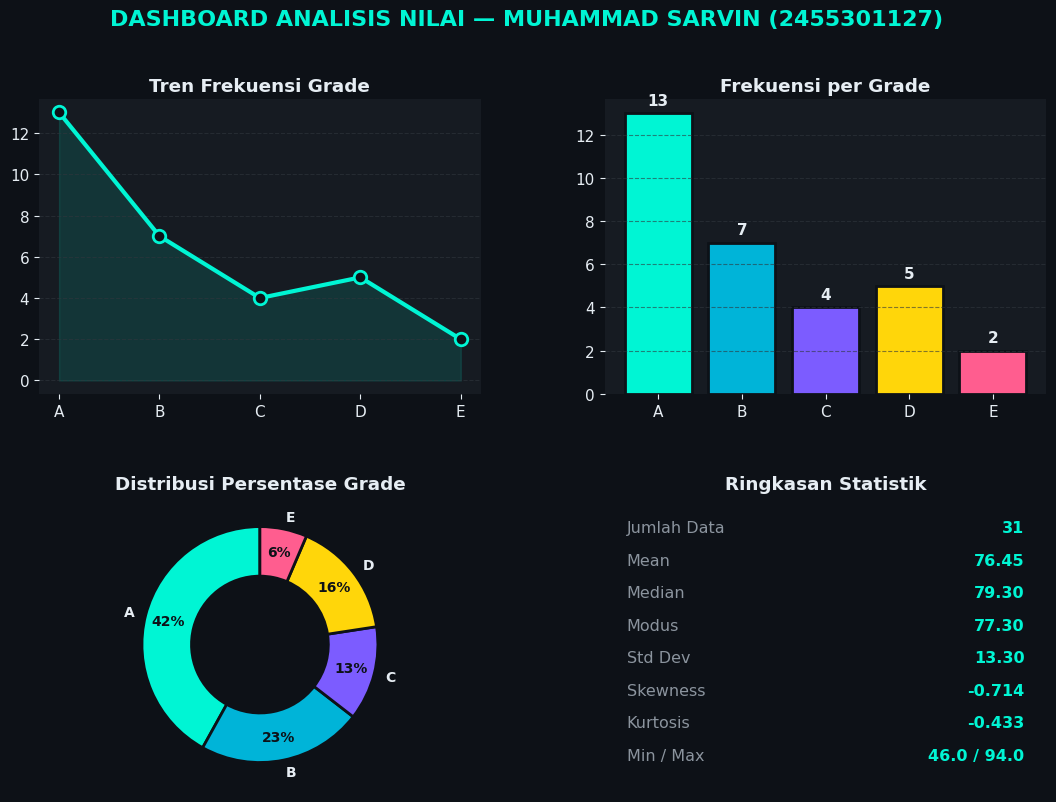

In [7]:


import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---------------------------------------------------------
# A. PENGORGANISASIAN DATA
# ---------------------------------------------------------
path = "sarvin.xlsx"
dataraw = pd.read_excel(path)
print("=== DATA MENTAH ===")
print(dataraw)

# ---------------------------------------------------------
# TEMA "IT STYLE" - dark theme + palet neon-tech
# ---------------------------------------------------------
plt.style.use("dark_background")
BG      = "#0D1117"
CARD    = "#161B22"
NEON    = ["#00F5D4", "#00B4D8", "#7C5CFF", "#FFD60A", "#FF5D8F"]
ACCENT  = "#00F5D4"
TEXT    = "#E6EDF3"
GRID    = "#30363D"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": CARD,
    "savefig.facecolor": BG, "text.color": TEXT,
    "axes.labelcolor": TEXT, "xtick.color": TEXT, "ytick.color": TEXT,
    "axes.edgecolor": GRID, "font.family": "DejaVu Sans", "font.size": 11,
})

# ---------------------------------------------------------
# B. PENYAJIAN DATA
# ---------------------------------------------------------
datafrq = pd.crosstab(index=dataraw["Grade"], columns="Frekuensi")
datafrq = datafrq.reindex(["A", "B", "C", "D", "E"])
print("\n=== TABEL FREKUENSI GRADE ===")
print(datafrq)

order = ["A", "B", "C", "D", "E"]
freq  = datafrq["Frekuensi"].values

# ---- 1. Grafik Garis ----
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(order, freq, marker="o", color=ACCENT, linewidth=3,
        markersize=10, markerfacecolor=BG, markeredgecolor=ACCENT, markeredgewidth=2)
ax.fill_between(order, freq, color=ACCENT, alpha=0.12)
for i, v in enumerate(freq):
    ax.annotate(str(v), (i, v), textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=12, fontweight="bold", color=ACCENT)
ax.set_title("GRAFIK GARIS — Frekuensi Grade", fontsize=14, fontweight="bold", color=TEXT, pad=15)
ax.set_xlabel("Grade"); ax.set_ylabel("Frekuensi")
ax.grid(axis="y", color=GRID, linestyle="--", alpha=0.6)
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout(); plt.savefig("grafik_garis.png", dpi=200); plt.show()

# ---- 2. Grafik Batang ----
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(order, freq, color=NEON, edgecolor=BG, linewidth=2, width=0.6)
for b in bars:
    h = b.get_height()
    ax.annotate(str(int(h)), (b.get_x() + b.get_width()/2, h),
                textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=12, fontweight="bold", color=TEXT)
ax.set_title("GRAFIK BATANG — Frekuensi Grade", fontsize=14, fontweight="bold", color=TEXT, pad=15)
ax.set_xlabel("Grade"); ax.set_ylabel("Frekuensi")
ax.grid(axis="y", color=GRID, linestyle="--", alpha=0.6)
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout(); plt.savefig("grafik_batang.png", dpi=200); plt.show()

# ---- 3. Pie / Donut Chart ----
fig, ax = plt.subplots(figsize=(6.5, 6.5))
pct = freq / freq.sum() * 100
wedges, _, autotexts = ax.pie(
    freq, labels=order, autopct="%1.1f%%", colors=NEON, startangle=90,
    pctdistance=0.8, wedgeprops={"width": 0.42, "edgecolor": BG, "linewidth": 3},
    textprops={"fontsize": 12, "fontweight": "bold", "color": TEXT})
for at in autotexts:
    at.set_color(BG); at.set_fontweight("bold")
ax.text(0, 0, f"n={freq.sum()}\nmahasiswa", ha="center", va="center",
        fontsize=13, fontweight="bold", color=ACCENT)
ax.set_title("PIE CHART — Persentase Grade", fontsize=14, fontweight="bold", color=TEXT, pad=15)
plt.tight_layout(); plt.savefig("grafik_pie.png", dpi=200); plt.show()

# ---------------------------------------------------------
# C. STATISTIKA DESKRIPTIF
# ---------------------------------------------------------
dataraw["Nilai"] = pd.to_numeric(dataraw["Nilai"], errors="coerce")
dt = dataraw["Nilai"]

stats = dt.describe()
stats["Standard Error"] = dt.sem()
stats["Median"]   = dt.median()
stats["Mode"]      = dt.mode().iloc[0]
stats["variance"]  = dt.var()
stats["range"]     = dt.max() - dt.min()
stats["skewness"]  = dt.skew()
stats["kurtosis"]  = dt.kurtosis()

print("\n=== STATISTIKA DESKRIPTIF - NILAI AKHIR ===")
print(stats)

# ---------------------------------------------------------
# D. DASHBOARD RINGKASAN (gabungan 4 panel - ciri khas "anak TI")
# ---------------------------------------------------------
fig = plt.figure(figsize=(13, 9))
fig.suptitle("DASHBOARD ANALISIS NILAI — MUHAMMAD SARVIN (2455301127)",
             fontsize=16, fontweight="bold", color=ACCENT, y=0.98)
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.28)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(order, freq, marker="o", color=ACCENT, linewidth=3, markersize=9,
         markerfacecolor=BG, markeredgecolor=ACCENT, markeredgewidth=2)
ax1.fill_between(order, freq, color=ACCENT, alpha=0.12)
ax1.set_title("Tren Frekuensi Grade", fontweight="bold", color=TEXT)
ax1.grid(axis="y", color=GRID, linestyle="--", alpha=0.6)
for s in ax1.spines.values(): s.set_visible(False)

ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(order, freq, color=NEON, edgecolor=BG, linewidth=2)
for b in bars:
    h = b.get_height()
    ax2.annotate(str(int(h)), (b.get_x()+b.get_width()/2, h), xytext=(0,6),
                 textcoords="offset points", ha="center", fontweight="bold")
ax2.set_title("Frekuensi per Grade", fontweight="bold", color=TEXT)
ax2.grid(axis="y", color=GRID, linestyle="--", alpha=0.6)
for s in ax2.spines.values(): s.set_visible(False)

ax3 = fig.add_subplot(gs[1, 0])
w, _, at = ax3.pie(freq, labels=order, autopct="%1.0f%%", colors=NEON, startangle=90,
                     pctdistance=0.8, wedgeprops={"width": 0.42, "edgecolor": BG, "linewidth": 2},
                     textprops={"fontsize": 10, "fontweight": "bold"})
for a in at: a.set_color(BG); a.set_fontweight("bold")
ax3.set_title("Distribusi Persentase Grade", fontweight="bold", color=TEXT)

ax4 = fig.add_subplot(gs[1, 1]); ax4.axis("off")
ringkasan = [
    ("Jumlah Data", f"{int(stats['count'])}"),
    ("Mean", f"{stats['mean']:.2f}"),
    ("Median", f"{stats['Median']:.2f}"),
    ("Modus", f"{stats['Mode']:.2f}"),
    ("Std Dev", f"{stats['std']:.2f}"),
    ("Skewness", f"{stats['skewness']:.3f}"),
    ("Kurtosis", f"{stats['kurtosis']:.3f}"),
    ("Min / Max", f"{stats['min']:.1f} / {stats['max']:.1f}"),
]
ax4.set_title("Ringkasan Statistik", fontweight="bold", color=TEXT, loc="center")
for i, (k, v) in enumerate(ringkasan):
    y = 0.88 - i*0.11
    ax4.text(0.05, y, k, fontsize=11.5, color="#8B949E", transform=ax4.transAxes)
    ax4.text(0.95, y, v, fontsize=11.5, fontweight="bold", color=ACCENT,
              ha="right", transform=ax4.transAxes)

plt.savefig("dashboard_sarvin.png", dpi=200, bbox_inches="tight")
plt.show()